<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/8-Function_Tranformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mathematical transformations
There are many types of mathematical transformation and these come under column transformation.
We need them to get a normal data i.e. a data having a normal distribution or normalPDF, whose peak is centred.


There are many ways to check if the data is normal or not:
1. sns.kdeplot()
2. pd.skew()

and the best way is a QQ Plot:



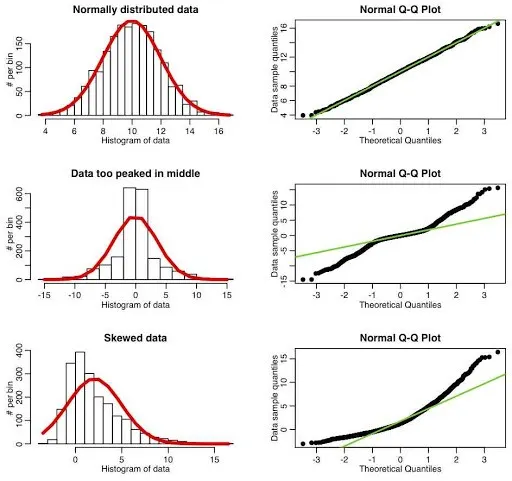
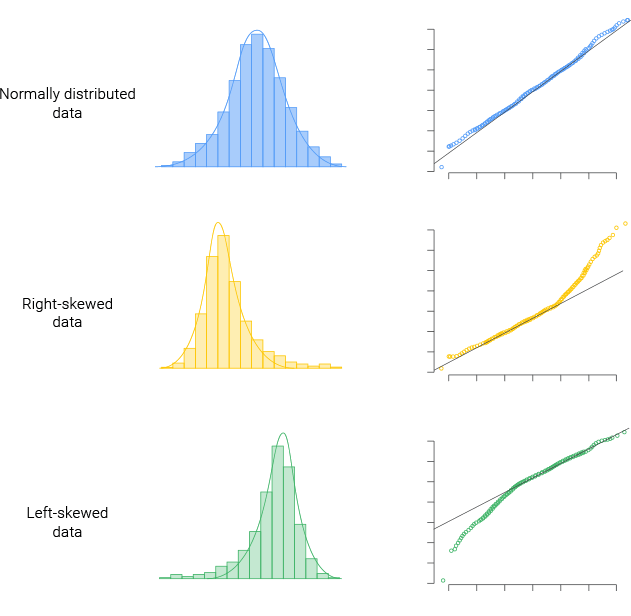

The more the qq plot sticks to the line inclined to 45 degree, the more normal the data is. The pattern of qqplot and the inclined line w.r.t. different type of data is clearly visible.

## IMPORTS

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import  LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

# Function Transformer


## 1. Log Transform
bada values ko chota kr deta h, additive scale ko multiplicitive scale mein convert kr deta h.

10, 100, 1000 ko 1, 2, 3 mein kr deta h [just an example with log base 10]

-Can't use on -ve values

-Used on right skewed data

## 2. Reciprocal Transform
chota value ko bada value mein convert kr deta h and vice versa. Might work on data that contain a RANGE of values.

## 3. Square Transform
works on left skewed data.

Jo bada values hai usko aur bada kr deta h hence expanding the range of values that are higher.

## 4. SquareRoot Transform
Square root krte hain.

Should work on right skewed data.

Can infere its working from above tranform.

Not mostly used (because log transform is superior?)

In [ ]:
df = pd.read_csv('drive/MyDrive/Datasets/train.csv',usecols=['Age','Fare','Survived'])

In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
df.fillna({'Age': df['Age'].mean()},inplace=True)

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X= df.iloc[:,1:]
y= df.iloc[:,0]

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'age qq plot')

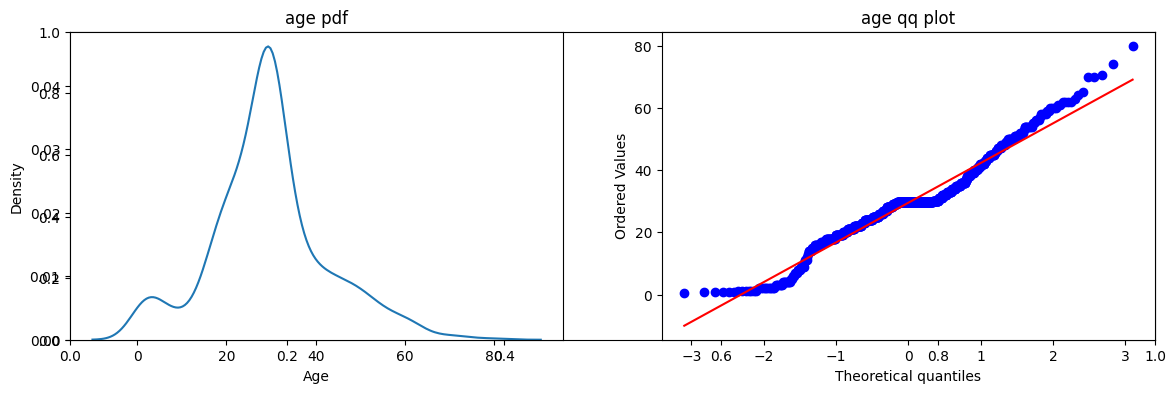

In [ ]:
plt.subplots(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(X_train['Age'])
plt.title('age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('age qq plot')

Text(0.5, 1.0, 'fare qq plot')

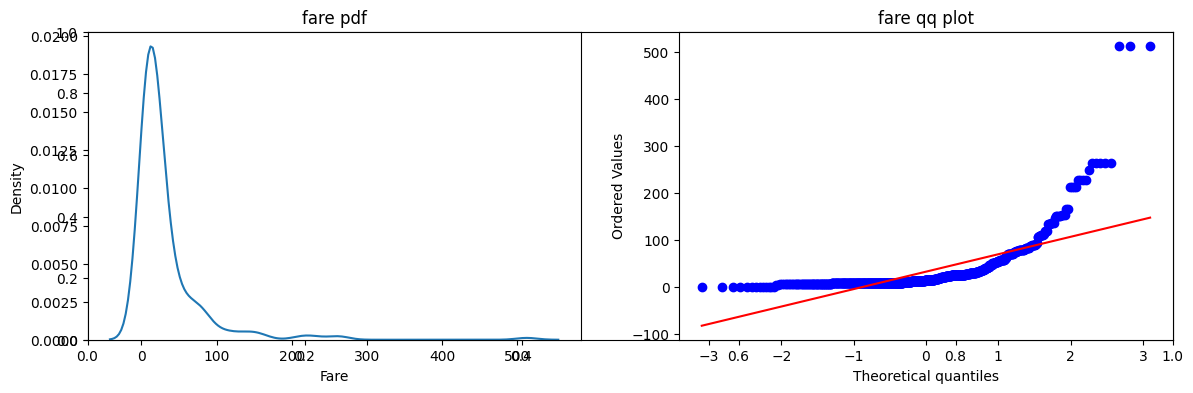

In [ ]:
plt.subplots(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(X_train['Fare'])
plt.title('fare pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('fare qq plot')

In [ ]:
clfl = LogisticRegression()
clft = DecisionTreeClassifier()

In [ ]:
clfl.fit(X_train, y_train)
clft.fit(X_train, y_train)

y_pred_l= clfl.predict(X_test)
y_pred_t= clft.predict(X_test)

print('Accuracy LR', accuracy_score(y_test,y_pred_l))
print('Accuracy DT', accuracy_score(y_test,y_pred_t))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6536312849162011


In [ ]:
trf= FunctionTransformer(func=np.log1p)

# 1p => 1 plus, it adds 1 to every data so it doesn't have to see zero

In [ ]:
X_train_transformed= trf.fit_transform(X_train)
X_test_transformed= trf.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.664804469273743


Clear increase in accuracy of LR

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_train_transformed,y_train,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_train_transformed,y_train,scoring='accuracy',cv=10)))

LR 0.6783646322378717
DT 0.61924882629108


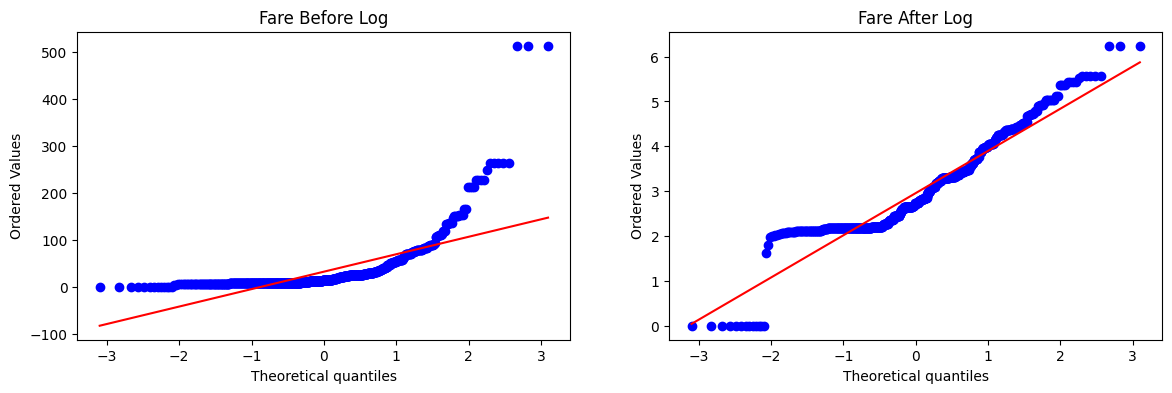

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

we can see that the fare column data has had an effect. It is more normalized!!

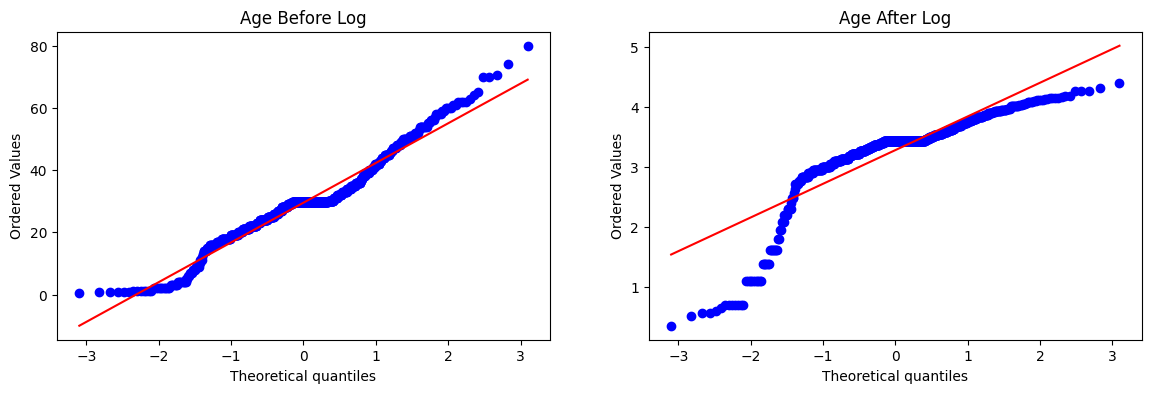

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

Age has also had some effect but in a negative sense because it is actually worse than before. So we will only apply log transformation to the fare column.

In [ ]:
tnf = ColumnTransformer([('log',FunctionTransformer(func=np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2= tnf.fit_transform(X_train)
X_test_transformed2=tnf.transform(X_test)


In [ ]:
X_train

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.659217877094972


No effect visible. looks deprecated even :(

In [ ]:
X_test_transformed.shape

(179, 2)

In [ ]:

def eval(x):
  trf = ColumnTransformer(transformers=[('toApply',FunctionTransformer(func=x),[0]),('log',FunctionTransformer(func=np.log1p),[1])],remainder='passthrough')
  # trf = FunctionTransformer(func=x)
  X_train_transformed3= trf.fit_transform(X_train)
  X_test_transformed3 = trf.transform(X_test)

  clf3 = LogisticRegression()
  clf3.fit(X_train_transformed3, y_train)
  y_pred3 = clf3.predict(X_test_transformed3)
  print(f"score = {accuracy_score(y_test,y_pred3)*100}%")

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.kdeplot(X_train_transformed3[:,0])

  plt.subplot(122)
  stats.probplot(X_train_transformed3[:,0], dist="norm", plot=plt)
  plt.title('Age After Log')

  plt.show()

score = 69.27374301675978%


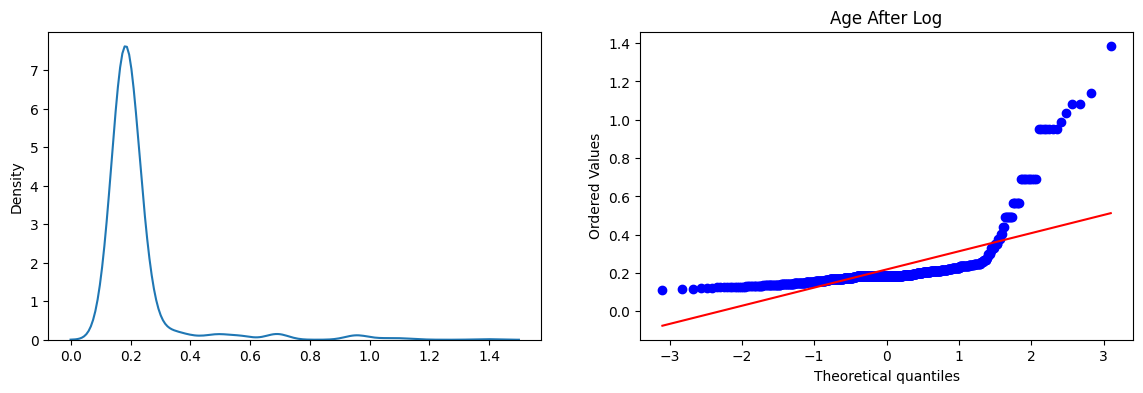

In [ ]:
eval(lambda x: (1/(x+0.1))**(1/2))

# [Power Transformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)



`class sklearn.preprocessing.PowerTransformer(method='yeo-johnson', *, standardize=True, copy=True)`



## Box-Cox Transform
### **$$ x^{(\lambda)} = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(x) & \text{if } \lambda = 0 \end{cases} $$**

The exponent here is a variable called lambda (λ) that varies over the range of -5 to 5, and in the process of searching, we examine all the values of λ. Finally, we choose the optimal value (resulting in the best approximation to a normal distribution) for your variable.


`
Problem with this is that x has to be greater than 0.
`




## Yeo - Johnson Transform
### $$ y^{(\lambda)} = \begin{cases} \frac{(y + 1)^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0, y \geq 0 \\ \ln(y + 1) & \text{if } \lambda = 0, y \geq 0 \\ -\frac{(-y + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{if } \lambda \neq 2, y < 0 \\ -\ln(-y + 1) & \text{if } \lambda = 2, y < 0 \end{cases} $$

This transformation is somewhat of an adjustment to the Box-Cox transformation, by which we can apply it to negative numbers.


In [3]:
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [4]:
df = pd.read_csv('drive/MyDrive/Datasets/concrete_data.csv')

In [5]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.info()

# No null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
X_train, X_test, y_train, y_test= train_test_split(df.drop(["Strength"], axis=1),df.Strength, test_size= 0.2, random_state=42)

In [9]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred= lr.predict(X_test)
print(r2_score(y_test, y_pred))

print(cross_val_score(lr,X_train,y_train, cv=10).mean())

0.627553179231485
0.5894185601991604


In [10]:
index = X_train.columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.to_numpy(),index)
X_test_scaled = scaler.transform(X_test.to_numpy())

In [11]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred= lr.predict(X_test_scaled)
print(r2_score(y_test, y_pred))

print(cross_val_score(lr,X_train,y_train, cv=10).mean())

0.627553179231485
0.5894185601991604


well scaling didn't have any effect because this data is not normalized and that is a bigger factor to take care of.

**Truth Nuke**: It is because this function doesn't f*cking use the gradient descent method. This uses the normal equation which involves inversing the matrix. It is very good for small data but big data requires GD method to be used.

In [12]:
# Applying box-cox transform even though it has zeroes.

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.0000000001)
X_test_transformed = pt.transform(X_test + 0.0000000001)

In [13]:
pd.DataFrame({'cols':X_train.columns, 'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.017671
2,Fly Ash,-0.025976
3,Water,0.772682
4,Superplasticizer,0.064135
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [14]:
lr = LinearRegression()

lr.fit(X_train_transformed, y_train)

y_pred = lr.predict(X_test_transformed)

print(r2_score(y_test, y_pred))
print(cross_val_score(lr, X_train_transformed, y_train, scoring='r2').mean())

0.8031951638748949
0.7920337480889014


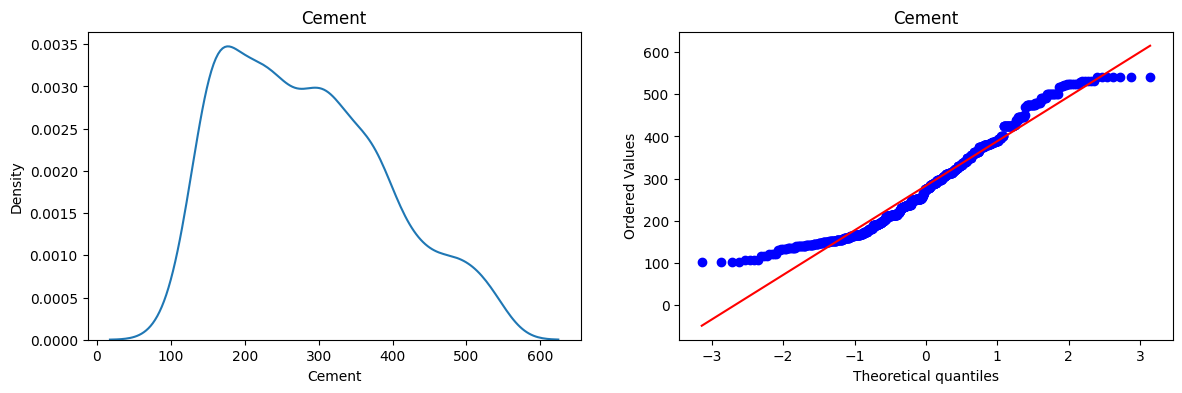

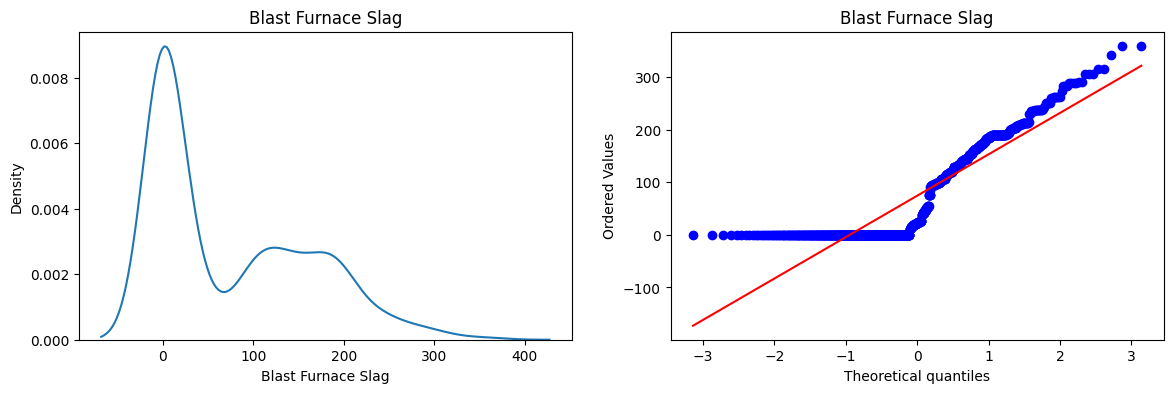

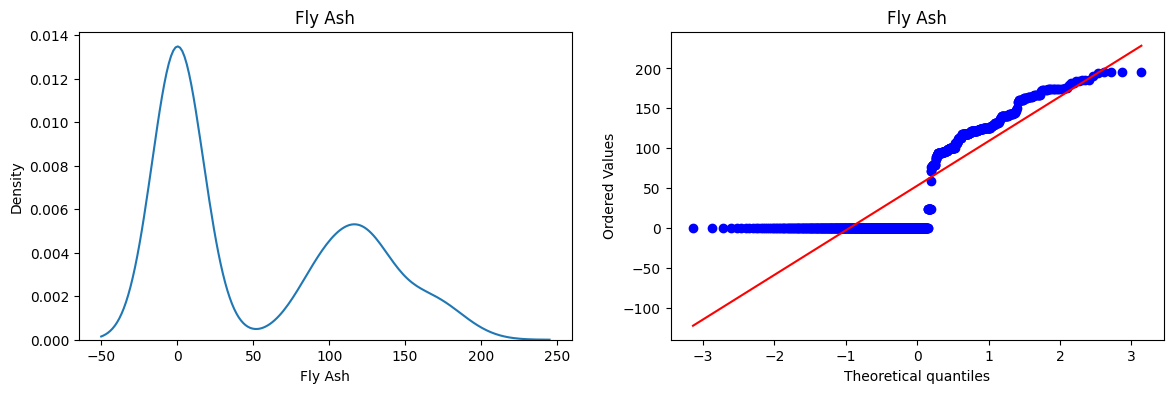

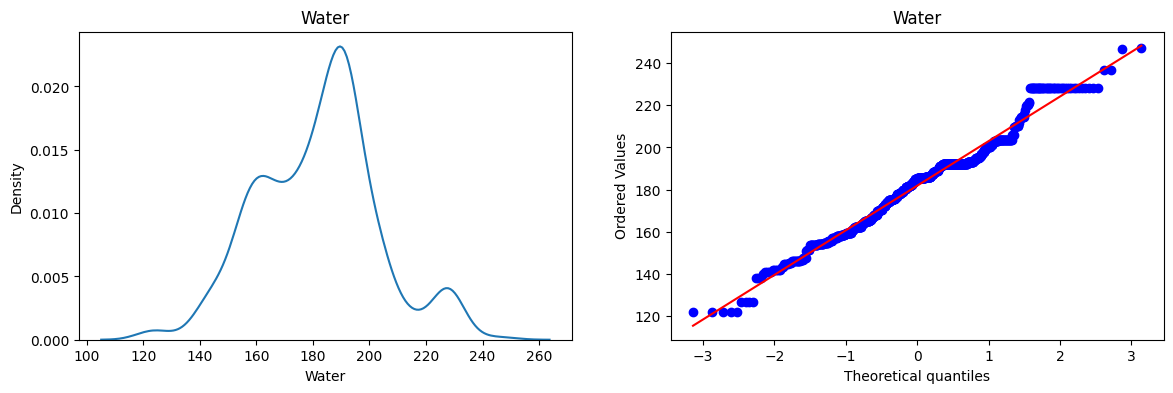

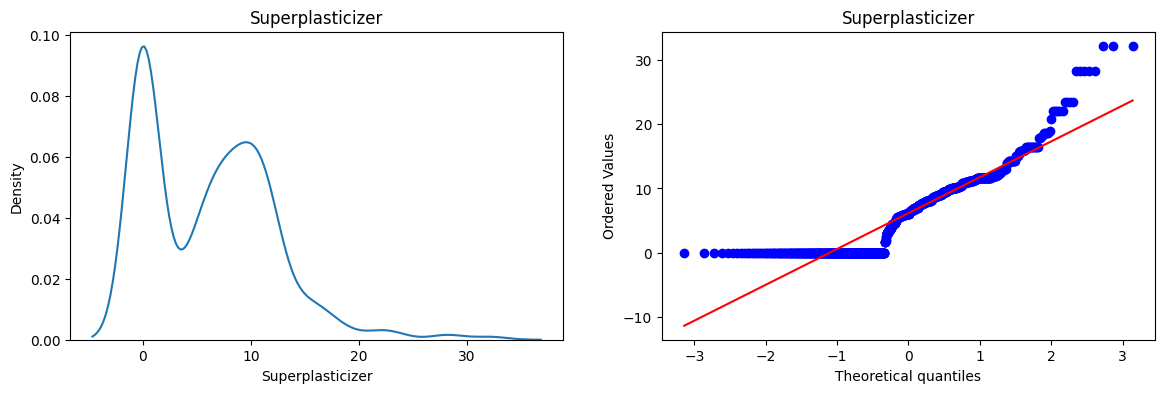

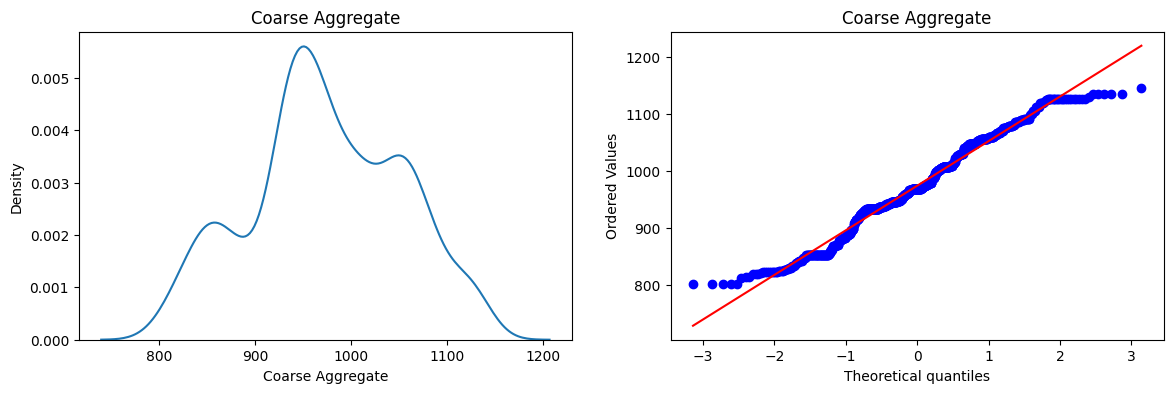

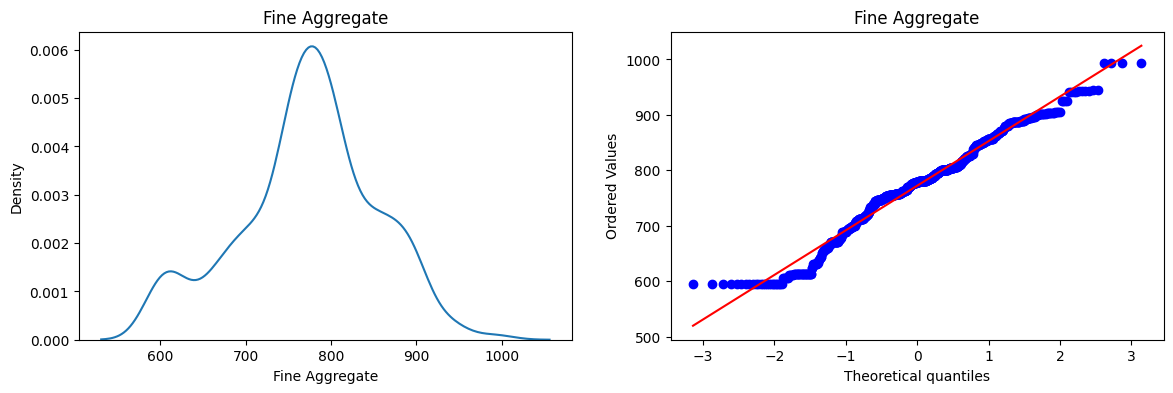

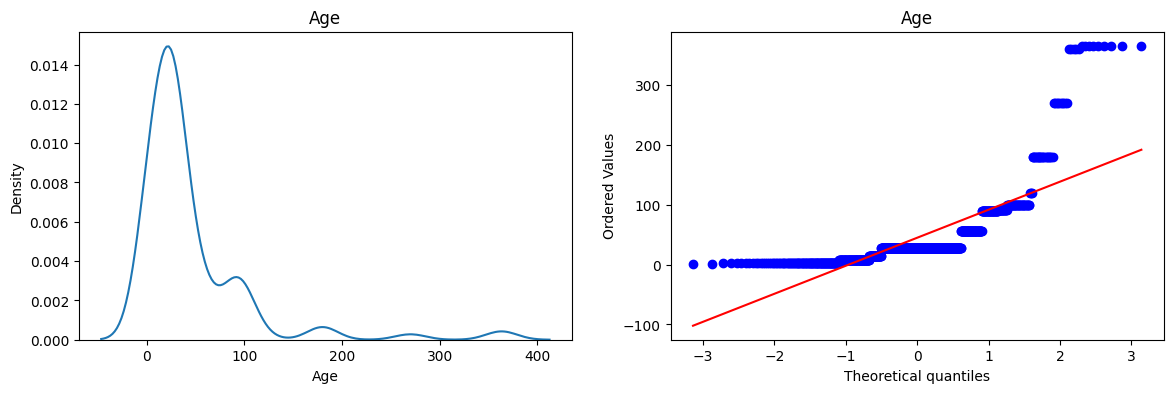

In [15]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

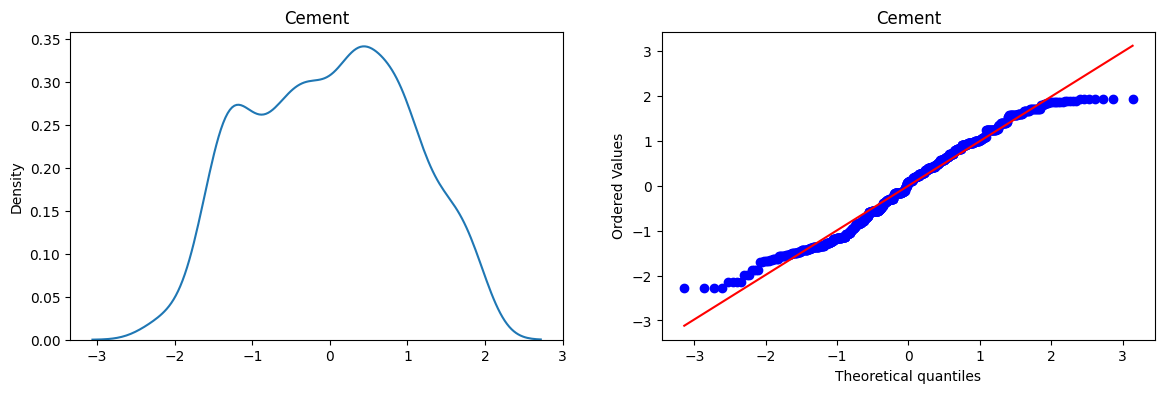

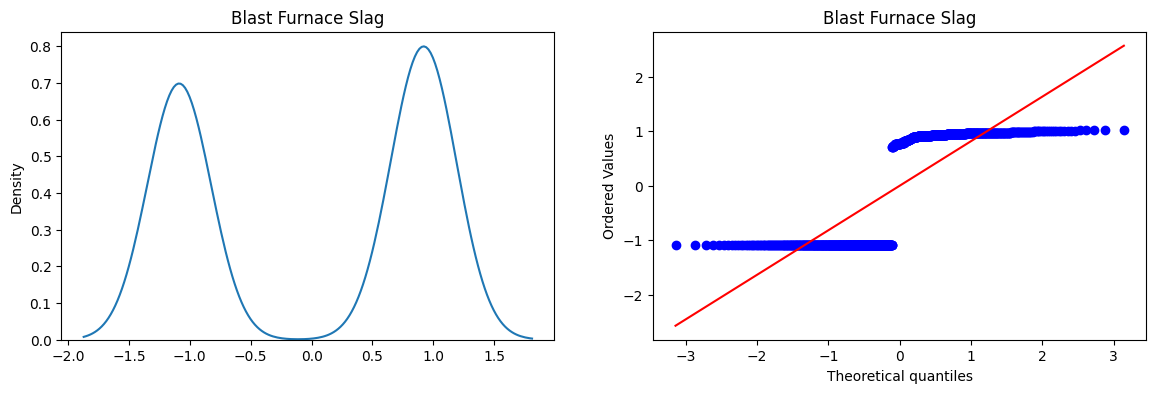

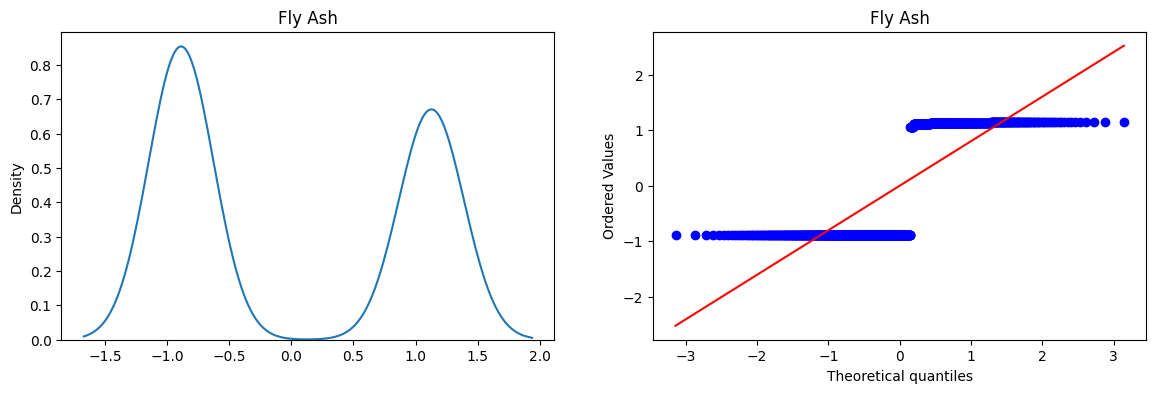

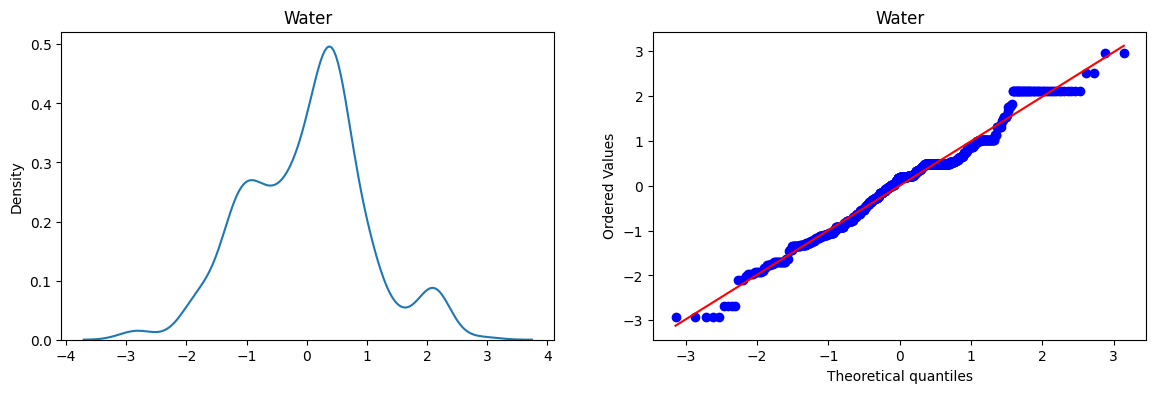

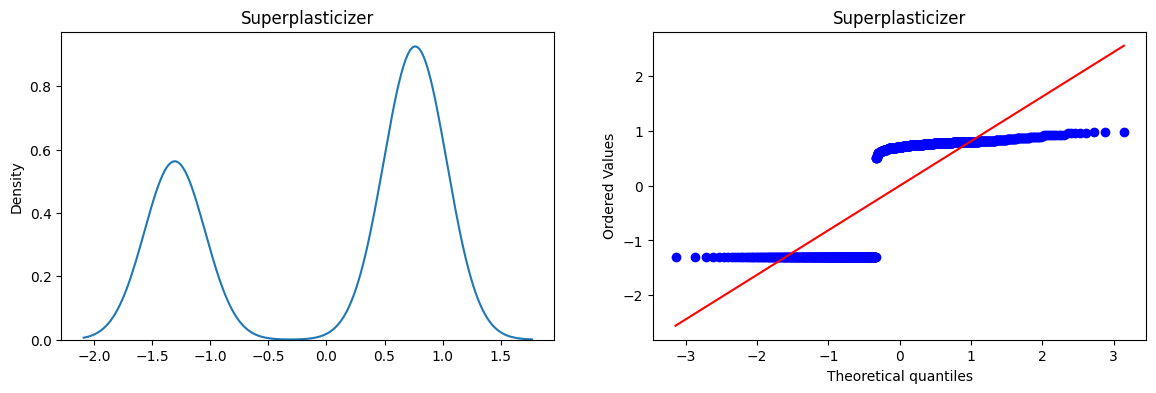

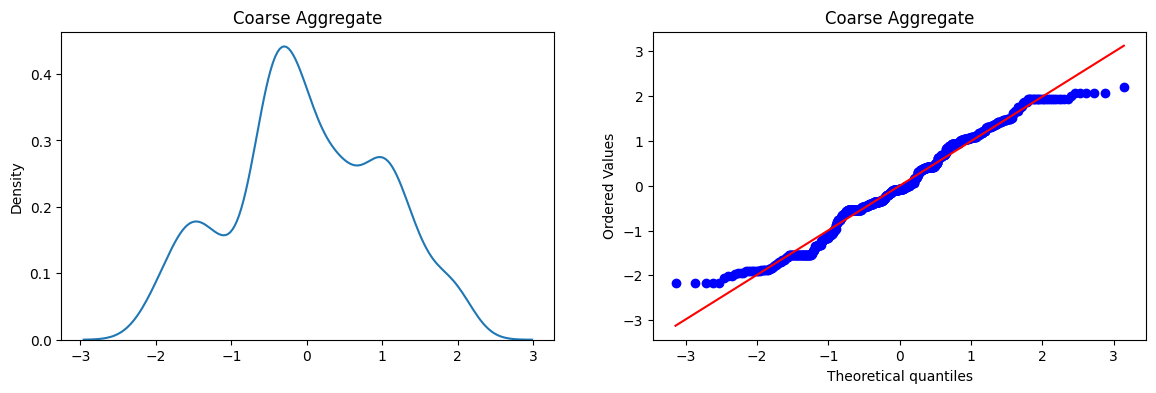

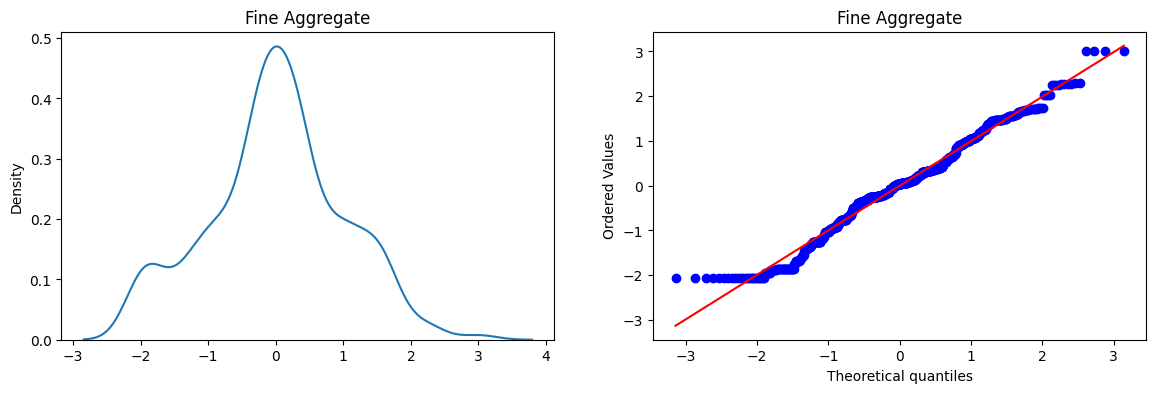

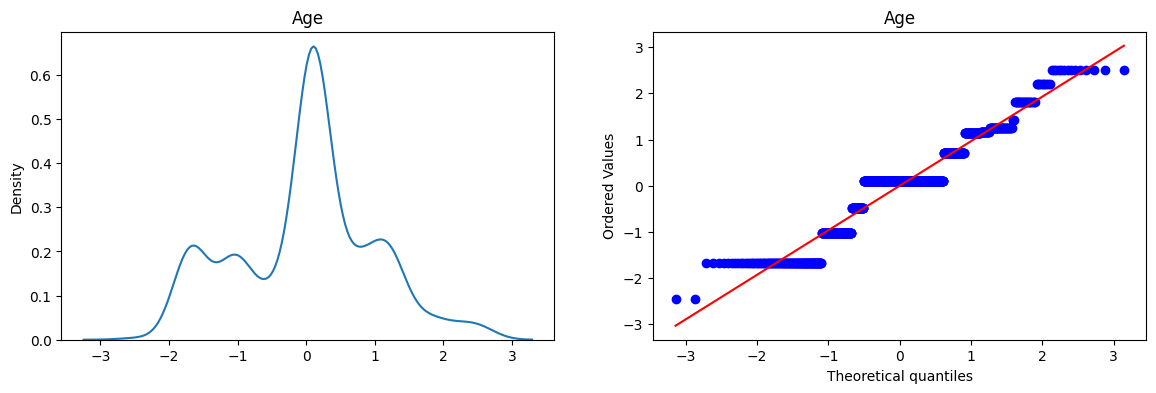

In [16]:
for l in range(len(X_train_transformed[0])):
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train_transformed[:,l])
    plt.title(X_train.columns[l])

    plt.subplot(122)
    stats.probplot(X_train_transformed[:,l], dist="norm", plot=plt)
    plt.title(X_train.columns[l])

    plt.show()

In [22]:
# lets see the scores with Yeo - Johnson

prt = PowerTransformer()
X_train_transformed1 = prt.fit_transform(X_train)
X_test_transformed1 = prt.transform(X_test)

lr1 = LinearRegression()
lr1.fit(X_train_transformed2, y_train)
y_pred1 = lr1.predict(X_test_transformed1)

print(r2_score(y_test,y_pred1))
print(f"For Yeo-johnson: {np.round(np.mean(cross_val_score(lr1, X_train_transformed1, y_train))*100,2)}%")
print(f"For Box-Cox: {np.round(np.mean(cross_val_score(lr, X_train_transformed, y_train))*100,2)}%")

0.8161906512004999
For Yeo-johnson: 79.42%
For Box-Cox: 79.2%


Yeo-Johnson mostly performs better than Box-Cox but we can try both its just change of one line of code :)